In [960]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

import folium
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


In [961]:
current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

data_path = project_root/"dataset"/"Bangladesh-Crime-Dataset.csv"

In [962]:
df = pd.read_csv(data_path)

In [963]:
df.head()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,latitude,longitude,incident_place,incident_district,...,literacy_rate,religious_institution,playground,park,police_station,cyber_cafe,school,college,cinema,crime
0,0,7,29,wednesday,0,morning,23.774569,90.355292,adabar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
1,1,1,2,wednesday,0,night,23.774569,90.355292,adabar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
2,2,1,4,tuesday,0,night,23.769808,90.351595,adabor,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
3,3,3,9,friday,1,night,23.728907,90.417137,aftabnagar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
4,4,8,34,thursday,0,night,23.847177,90.404133,airport,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder


In [964]:
df.shape

(6574, 38)

In [965]:
df["weekend"].unique()

array([0, 1])

In [966]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [967]:
df.head(25)

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,latitude,longitude,incident_place,incident_district,incident_division,...,literacy_rate,religious_institution,playground,park,police_station,cyber_cafe,school,college,cinema,crime
0,7,29,wednesday,0,morning,23.774569,90.355292,adabar,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
1,1,2,wednesday,0,night,23.774569,90.355292,adabar,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
2,1,4,tuesday,0,night,23.769808,90.351595,adabor,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
3,3,9,friday,1,night,23.728907,90.417137,aftabnagar,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
4,8,34,thursday,0,night,23.847177,90.404133,airport,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
5,8,34,thursday,0,night,23.847177,90.404133,airport,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
6,2,7,sunday,0,night,23.913894,90.320686,ashulia,dhaka,dhaka,...,68.0,1118,78,3,6,16,42,10,3,murder
7,1,1,saturday,1,evening,23.913894,90.320686,ashulia,dhaka,dhaka,...,68.0,1118,78,3,6,16,42,10,3,murder
8,1,2,friday,1,evening,23.913894,90.320686,ashulia,dhaka,dhaka,...,68.0,1118,78,3,6,16,42,10,3,murder
9,2,7,sunday,0,night,23.913894,90.320686,ashulia,dhaka,dhaka,...,68.0,1118,78,3,6,16,42,10,3,murder


In [968]:
df.gender_ration.unique()

array([125, 114, 101,  90, 113,  88, 116,  97,  96, 102,  98,  99, 110,
        94,  89,  86, 109, 107, 108, 100,  93, 103, 105, 104,  95, 117,
        91,  92, 106, 111, 203,  85,  84,  87])

In [969]:
df_copy = df.copy()

In [970]:
df.isna().sum().sum()

np.int64(0)

In [971]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          6574 non-null   int64  
 1   incident_week           6574 non-null   int64  
 2   incident_weekday        6574 non-null   str    
 3   weekend                 6574 non-null   int64  
 4   part_of_the_day         6574 non-null   str    
 5   latitude                6574 non-null   float64
 6   longitude               6574 non-null   float64
 7   incident_place          6574 non-null   str    
 8   incident_district       6574 non-null   str    
 9   incident_division       6574 non-null   str    
 10  max_temp                6574 non-null   int64  
 11  avg_temp                6574 non-null   int64  
 12  min_temp                6574 non-null   int64  
 13  weather_code            6574 non-null   int64  
 14  precip                  6574 non-null   float64
 15

## The dataset contains crime events collected over seven years. However, since exact dates and years are unavailable, the temporal features are analyzed as recurring seasonal and weekly patterns rather than as a chronological seven-year timeline.

In [972]:
crime_details = df.groupby(["incident_place", "incident_month", "incident_week", "incident_weekday"])["crime"].count()
print(crime_details)

incident_place  incident_month  incident_week  incident_weekday
abhaynagar      1               2              sunday              1
                                4              saturday            1
                2               7              friday              1
                                8              sunday              1
                                               thursday            1
                                                                  ..
zianagar        6               22             saturday            1
                7               30             thursday            1
                8               35             friday              1
                9               37             saturday            1
                10              40             wednesday           1
Name: crime, Length: 5858, dtype: int64


In [973]:
df.describe()

,incident_month,incident_week,weekend,latitude,longitude,max_temp,avg_temp,min_temp,weather_code,precip,...,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,cyber_cafe,school,college,cinema
count,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,...,6574.000000,6574.000000,6574.00000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000
mean,6.193185,25.193946,0.273806,23.889900,90.213444,32.673258,29.214481,24.114694,222.257225,6.187998,...,6362.512017,55.748829,1232.03164,42.504411,3.863706,11.771372,72.312443,75.218893,15.479617,7.396714
std,3.321934,14.517965,0.445944,1.051299,1.004609,3.452756,3.511377,3.982991,116.678263,11.989998,...,10368.342248,12.045279,1245.17044,44.857967,5.883186,19.612903,160.570311,71.743767,19.721917,12.935065
min,1.000000,1.000000,0.000000,20.866700,88.141700,17.000000,16.000000,8.000000,113.000000,0.000000,...,23.000000,26.700000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,3.000000,13.000000,0.000000,23.180315,89.375000,31.000000,27.000000,21.000000,113.000000,0.000000,...,924.000000,46.800000,519.00000,5.000000,0.000000,2.000000,0.000000,30.000000,4.000000,1.000000
50%,6.000000,25.000000,0.000000,23.858330,90.268302,33.000000,30.000000,25.000000,176.000000,0.800000,...,1239.000000,53.900000,818.00000,25.000000,1.000000,3.000000,1.000000,45.000000,8.000000,2.000000
75%,9.000000,37.000000,1.000000,24.585009,90.652500,35.000000,32.000000,27.000000,356.000000,7.500000,...,3977.000000,67.200000,1125.00000,78.000000,3.000000,6.000000,16.000000,86.000000,15.000000,5.000000
max,12.000000,53.000000,1.000000,26.482740,92.437760,45.000000,40.000000,32.000000,389.000000,204.600000,...,30551.000000,74.600000,4289.00000,253.000000,17.000000,74.000000,478.000000,242.000000,64.000000,40.000000


## Descriptive Analysis

- Found outlier in gender_ration, gender_ration basically indicates how many men there are for every 100 women in an area. It seems 2:1 ratio present in dataset in 4th quartile. Its quite suspicious. From other fields like playground, park, police_station, cyber_cafe, school and college also may have outliers. Lets check boxplot.

In [974]:
df.isna().sum().sum()

np.int64(0)

## Temporal Analysis

In [975]:
week_wise_crime_avg = df.groupby("incident_weekday")["crime"].value_counts(ascending=False)
print(week_wise_crime_avg)

incident_weekday  crime    
friday            murder       216
                  bodyfound    208
                  rape         171
                  assault      134
                  kidnap        86
                  robbery       68
monday            murder       236
                  bodyfound    226
                  assault      165
                  rape         164
                  robbery      110
                  kidnap        83
saturday          bodyfound    228
                  murder       204
                  rape         152
                  assault      150
                  kidnap       109
                  robbery       74
sunday            murder       194
                  bodyfound    179
                  rape         166
                  assault      152
                  kidnap        92
                  robbery       84
thursday          bodyfound    234
                  murder       192
                  rape         179
                  assault  

In [976]:
total_crime_per_weekday = df["incident_weekday"].value_counts()
print(f"Maximum crime on each weekday:\n {total_crime_per_weekday}")

Maximum crime on each weekday:
 incident_weekday
tuesday      1010
monday        984
wednesday     976
thursday      937
saturday      917
friday        883
sunday        867
Name: count, dtype: int64


In [977]:
murder_df = df[df["crime"] == "murder"]
murder_per_weekday = murder_df["incident_weekday"].value_counts(ascending=False)
print(f"Murder summery:\n{murder_per_weekday}")

Murder summery:
incident_weekday
tuesday      241
monday       236
wednesday    235
friday       216
saturday     204
sunday       194
thursday     192
Name: count, dtype: int64


In [978]:
df['incident_week'].unique()

array([29,  2,  4,  9, 34,  7,  1, 46, 45, 36, 23, 14, 31, 19, 37,  3, 16,
       12, 44, 26, 40, 21, 24, 10,  5, 11, 35, 25,  8, 28, 32, 30,  6, 17,
       20, 22, 18, 49, 51, 33, 43, 52, 15, 27, 38, 13, 42, 48, 47, 41, 39,
       50, 53])

In [979]:
unique_weeks_per_weekday = df.groupby("incident_weekday")["incident_week"].nunique()
avg_murder_per_weekday = murder_per_weekday/unique_weeks_per_weekday
print(f"Average murder on every weekday:\n {avg_murder_per_weekday}")


Average murder on every weekday:
 incident_weekday
friday       4.075472
monday       4.452830
saturday     3.849057
sunday       3.660377
thursday     3.622642
tuesday      4.547170
wednesday    4.433962
dtype: float64


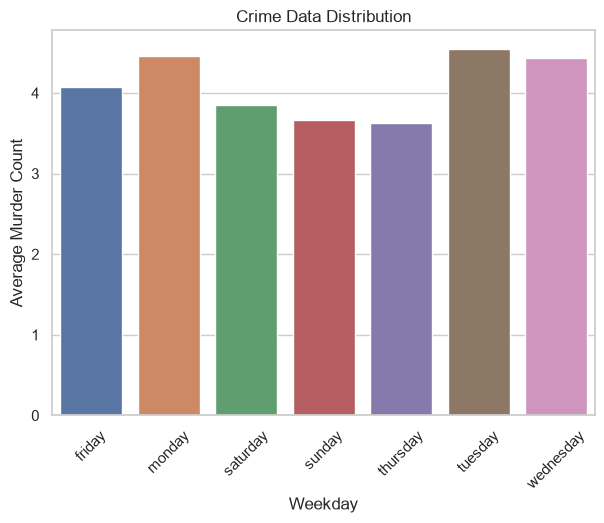

In [980]:
plt.figure(figsize=(7,5))
sns.barplot(x = avg_murder_per_weekday.index,y = avg_murder_per_weekday.values, hue=["skyblue", "orange", "green", "maroon", "brown", "blue", "purple"], legend=False)
plt.title("Crime Data Distribution")
plt.xlabel("Weekday")
plt.ylabel("Average Murder Count")
plt.xticks(rotation=45)
plt.show()

In [981]:
df["crime"].unique()

<StringArray>
['murder', 'rape', 'assault', 'bodyfound', 'kidnap', 'robbery']
Length: 6, dtype: str

In [982]:
map_df = df.groupby(["incident_place", "latitude", "longitude", "crime"]).size().reset_index(name='total_crimes')
bd_map = folium.Map(location=[23.6850, 90.3563], zoom_start=7, tiles="OpenStreetMap")
#crime wise color selestion
clr_map = {
    "murder":"red",
    "bodyfound":"darkred",
    "rape":"purple",
    "assault":"orange",
    "kidnap":"blue",
    "robbery":"green"
}
for idx, row in map_df.iterrows():
    #if not crime in group list--> default clr:gray
    m_clr = clr_map.get(row["crime"], "gray")

    folium.CircleMarker(
        location = [row["latitude"], row["longitude"]],
        radius = min(row["total_crimes"] * 0.5,20),
        popup = f"<b>Place:</b> {row['incident_place']}<br><b>Crime:</b> {row['crime']}<br><b>Total:</b> {row["total_crimes"]}",
        color = m_clr,
        fill=True,
        fill_color=True,
        fill_opacity=0.6
        ).add_to(bd_map)


bd_map

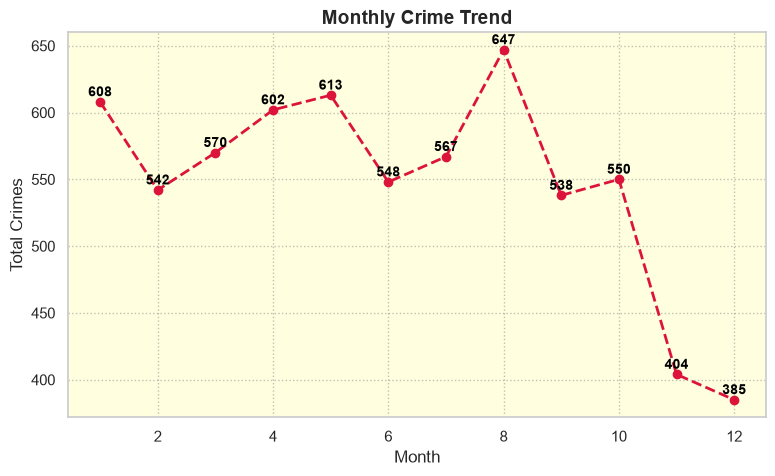

In [983]:
#monthly crime
monthly_counts = df.groupby('incident_month').size()

plt.figure(figsize=(9, 5))


ax = plt.gca()
ax.set_facecolor('lightyellow') 


plt.plot(monthly_counts.index, monthly_counts.values, marker='o', linestyle="--", color="crimson", linewidth=2)

for x, y in zip(monthly_counts.index, monthly_counts.values):
    plt.text(x, y + 2, str(y), ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')
    # y + 2, to move 2 tiles upward

plt.title("Monthly Crime Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Crimes", fontsize=12)

plt.grid(True, linestyle=':', alpha=0.5, color='gray')
plt.show()


### Monthly Crime Analysis
- It seems most of the time crime goes peak in August.

In [984]:
df.season.unique()

<StringArray>
['rainy', 'winter', 'hot']
Length: 3, dtype: str

In [985]:
season_crime = df.groupby("season")["crime"].count()
season_crime

season
hot       1785
rainy     2850
winter    1939
Name: crime, dtype: int64

In [986]:
df_enc = pd.get_dummies(df, columns=["season","crime"], drop_first=True)

## Spatial Analysis

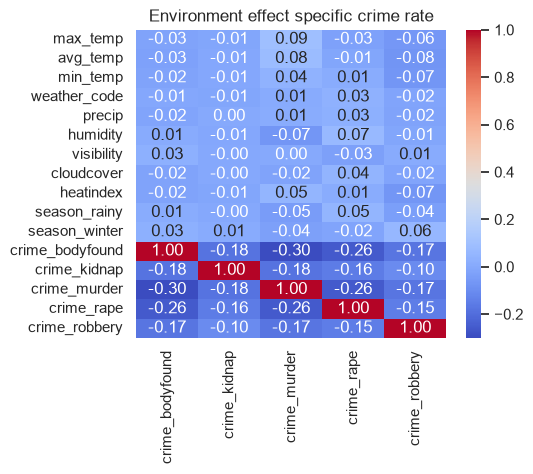

In [987]:
environment_features = ["max_temp", "avg_temp", "min_temp", "weather_code", "precip", "humidity", "visibility", "cloudcover", "heatindex"]
dummy_cols = [col for col in df_enc.columns if col.startswith("season_")]
crime_col = [col for col in df_enc.columns if col.startswith("crime_")]
env_feature = environment_features+dummy_cols+crime_col

env_corr = df_enc[env_feature].corr()

plt.figure(figsize=(5,4))
sns.heatmap(env_corr.loc[env_feature, crime_col], annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Environment effect specific crime rate")
plt.show()


## Heatmap Analysis
- Crime type dummy variables exhibit expected negative correlations because each incident belongs to exactly one crime category. Therefore, these correlations are a consequence of one-hot encoding rather than evidence of an inverse relationship between different crime types.

In [988]:
#what is park & police station effect crime rate
crime_summery = df.groupby(["park", "police_station"]).size().reset_index(name="total_crimes")
print(crime_summery)


    park  police_station  total_crimes
0      0               0            28
1      0               1           795
2      0               2           784
3      0               3           475
4      0               4           171
5      0               5            82
6      0               6            45
7      0               7           107
8      0               8            26
9      0              10            14
10     0              12            10
11     1               1           341
12     1               2           336
13     1               3           231
14     1               4            45
15     1               5           132
16     1               6            62
17     1               8            12
18     1              10             8
19     1              74             2
20     2               1            86
21     2               2           358
22     2               3            34
23     2               4            18
24     2               5 

In [989]:
#place wise crime
place_wise_crime = df.groupby("incident_place")["crime"].count().reset_index(name="total_crimes").sort_values(by="total_crimes", ascending=False)
print(f"Place wise total crimes:\n{place_wise_crime}")

Place wise total crimes:
                     incident_place  total_crimes
131                 chattogram city           224
566                           savar           194
624                    sylhet sadar            96
519                   rajshahi city            85
285                   jessore sadar            81
..                              ...           ...
601  sir salimullah medical college             1
651                   uttar kattali             1
611                 south sunamganj             1
26                           atpara             1
654                          vatara             1

[660 rows x 2 columns]


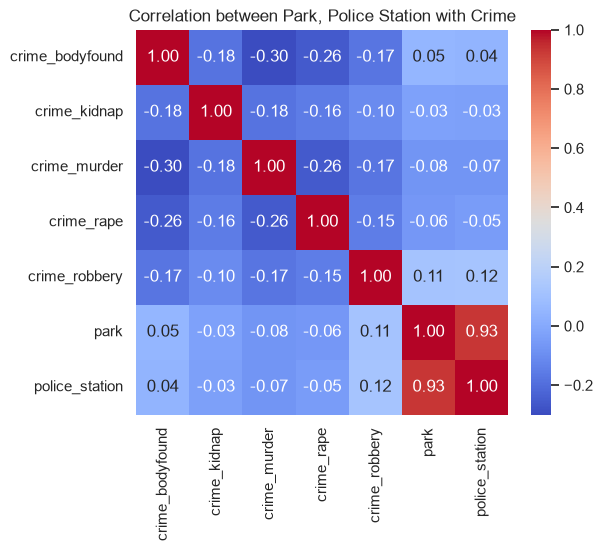

In [990]:
#correlation between park, police station and crime
crime_col = crime_col+["park","police_station"]
crime_corr = df_enc[crime_col].corr()

plt.figure(figsize=(6,5))
sns.heatmap(crime_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Park, Police Station with Crime")
plt.show()

## Heatmap Analysis

- There is no significant correlation observed. Lets try aggregating this three feature in a separate data frame and then check again.

In [991]:
same_place = df[(df["incident_place"] == "adabor") | (df["incident_place"] == "adabar")]
print(same_place)

     incident_month  incident_week incident_weekday  weekend part_of_the_day  \
0                 7             29        wednesday        0         morning   
1                 1              2        wednesday        0           night   
2                 1              4          tuesday        0           night   
559              12             52         thursday        0         morning   
560               3             10         thursday        0           night   
561               1              2           friday        1         morning   
887               7             26           sunday        0         morning   
902               7             30         thursday        0         morning   

      latitude  longitude incident_place incident_district incident_division  \
0    23.774569  90.355292         adabar             dhaka             dhaka   
1    23.774569  90.355292         adabar             dhaka             dhaka   
2    23.769808  90.351595         adabo

In [992]:
df["incident_place"] = df["incident_place"].replace("adabar","adabor")

In [993]:
place_summery = df.groupby("incident_place").agg(
    total_crimes = ('crime', 'count'),
    total_park = ('park', 'nunique'),
    total_field = ('playground', 'nunique'),
    total_police_station = ('police_station', 'nunique')
).reset_index()

In [994]:
place_summery.sort_values(by="total_crimes", ascending=False)

,incident_place,total_crimes,total_park,total_field,total_police_station
130,chattogram city,224,1,1,1
565,savar,194,1,1,1
623,sylhet sadar,96,1,1,1
518,rajshahi city,85,1,1,1
284,jessore sadar,81,1,1,1
...,...,...,...,...,...
600,sir salimullah medical college,1,1,1,1
178,dholaikhal,1,1,1,1
653,vatara,1,1,1,1
650,uttar kattali,1,1,1,1


## Place Summery
- These locations appear to have fewer parks/playgrounds/police stations alongside higher crime counts. Further statistical analysis is required before inferring any relationship

In [995]:
#In which place in which time what type of crime is more often occurs
crime_analysis = df.groupby(["incident_place", "part_of_the_day", "crime"]).size().reset_index(name="crime_count")

most_frequent_daytime = crime_analysis.loc[crime_analysis.groupby(["incident_place","part_of_the_day"])["crime_count"].idxmax()]
most_frequent_daytime.head()

,incident_place,part_of_the_day,crime,crime_count
0,abhaynagar,afternoon,assault,1
1,abhaynagar,morning,murder,2
5,abhaynagar,night,rape,5
6,abhaynagar,noon,bodyfound,1
8,adabor,morning,bodyfound,2


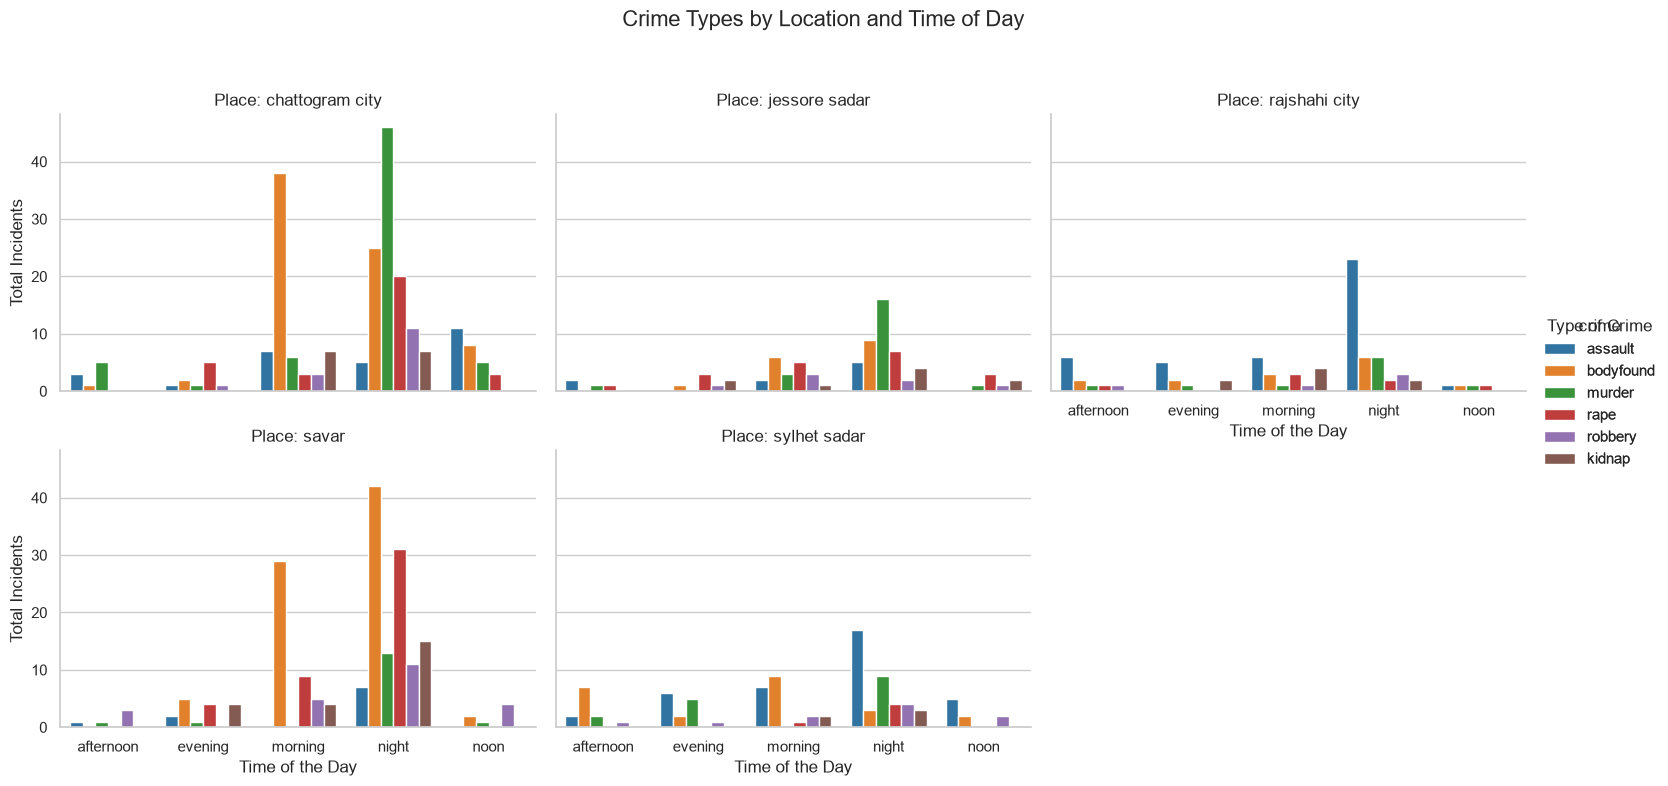

In [996]:
#top crime spots
top_places = df["incident_place"].value_counts().nlargest(5).index
df_filtered = crime_analysis[crime_analysis["incident_place"].isin(top_places)]

# catplot
graph = sns.catplot(
    data=df_filtered,
    x="part_of_the_day",
    y="crime_count",
    hue="crime",
    col="incident_place",  # separate colum for each place
    kind="bar",
    col_wrap=3,            #each line shows 3 graph
    palette="tab10",
    height=4,
    aspect=1.2
)


graph.set_axis_labels("Time of the Day", "Total Incidents")
graph.set_titles("Place: {col_name}")
graph.add_legend(title="Type of Crime")
plt.subplots_adjust(top=0.85)
graph.fig.suptitle("Crime Types by Location and Time of Day", fontsize=16)

plt.show()


In [997]:
highly_populated = df.groupby("incident_place").agg(
    total_crime = ('crime', 'count'),
    total_population = ('total_population', 'max'),
    density_per_kmsq = ('density_per_kmsq', 'max')
).reset_index().sort_values(by="total_crime",ascending=False)

#population remain constant within each place, so max() is used as representative value

highly_populated

,incident_place,total_crime,total_population,density_per_kmsq
130,chattogram city,224,2592439,20190
565,savar,194,1385910,4948
623,sylhet sadar,96,343965,2747
518,rajshahi city,85,449756,4318
284,jessore sadar,81,742898,1707
...,...,...,...,...
600,sir salimullah medical college,1,8906039,30551
178,dholaikhal,1,8906039,30551
653,vatara,1,8906039,30551
650,uttar kattali,1,2592439,20190


In [998]:
highly_populated.sort_values(by="density_per_kmsq", ascending=False)

,incident_place,total_crime,total_population,density_per_kmsq
29,azampur,1,8906039,30551
297,kachukhet,1,8906039,30551
34,badamtoli ghat,1,8906039,30551
567,segunbagicha,1,8906039,30551
571,shaheed suhrawardy medical college hospital,1,8906039,30551
...,...,...,...,...
543,ruma,7,29038,59
14,alikadam,7,49317,56
40,baghaichari,7,96899,50
77,belaichari,5,28525,38


## Observation
- No strong monotonic relationship observed. There is non linear relation in occuring crimes.

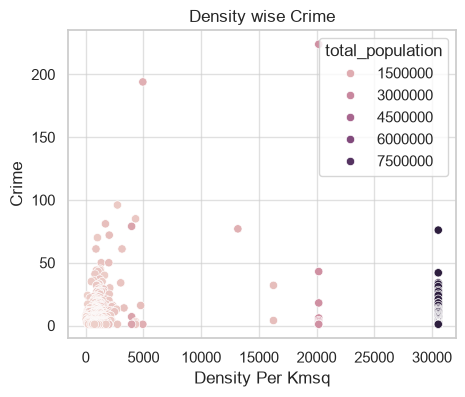

In [999]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=highly_populated, x="density_per_kmsq", y="total_crime", hue="total_population")
plt.title("Density wise Crime")
plt.xlabel("Density Per Kmsq")
plt.ylabel("Crime")
plt.grid(alpha=0.6)
plt.show()

In [1000]:
correlation = highly_populated['total_crime'].corr(highly_populated['density_per_kmsq'])
print(f"Area wise correlation between crime and population density: {correlation}")

Area wise correlation between crime and population density: -0.13127780425283037


In [1001]:
police_station_wise_crime = df.groupby("incident_place").agg(
    total_crime = ('crime', 'count'),
    total_station = ('police_station','max')
).reset_index().sort_values(by='total_crime', ascending=False)

police_station_wise_crime

,incident_place,total_crime,total_station
130,chattogram city,224,26
565,savar,194,6
623,sylhet sadar,96,4
518,rajshahi city,85,4
284,jessore sadar,81,11
...,...,...,...
600,sir salimullah medical college,1,60
178,dholaikhal,1,60
653,vatara,1,60
650,uttar kattali,1,26


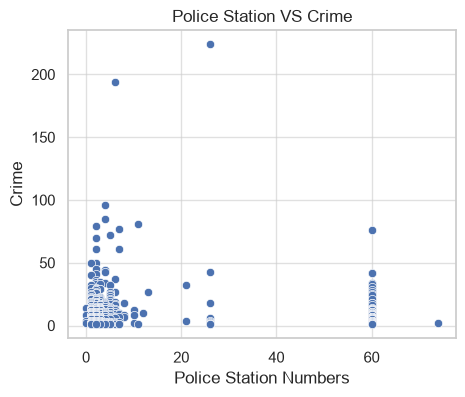

In [1002]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=police_station_wise_crime, x="total_station", y="total_crime")
plt.title("Police Station VS Crime")
plt.xlabel("Police Station Numbers")
plt.ylabel("Crime")
plt.grid(alpha=0.6)
plt.show()

## Observation
- Also police station and occuring crime shows non linear pattern.

In [1003]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          6574 non-null   int64  
 1   incident_week           6574 non-null   int64  
 2   incident_weekday        6574 non-null   str    
 3   weekend                 6574 non-null   int64  
 4   part_of_the_day         6574 non-null   str    
 5   latitude                6574 non-null   float64
 6   longitude               6574 non-null   float64
 7   incident_place          6574 non-null   str    
 8   incident_district       6574 non-null   str    
 9   incident_division       6574 non-null   str    
 10  max_temp                6574 non-null   int64  
 11  avg_temp                6574 non-null   int64  
 12  min_temp                6574 non-null   int64  
 13  weather_code            6574 non-null   int64  
 14  precip                  6574 non-null   float64
 15

In [1004]:
weather_crimes = df.groupby("incident_place").agg(
    total_crimes = ('crime','count'),
    weather_code = ('weather_code', 'max')
)
top_10_crime_weather = weather_crimes.sort_values(by="total_crimes", ascending=False).head(10)

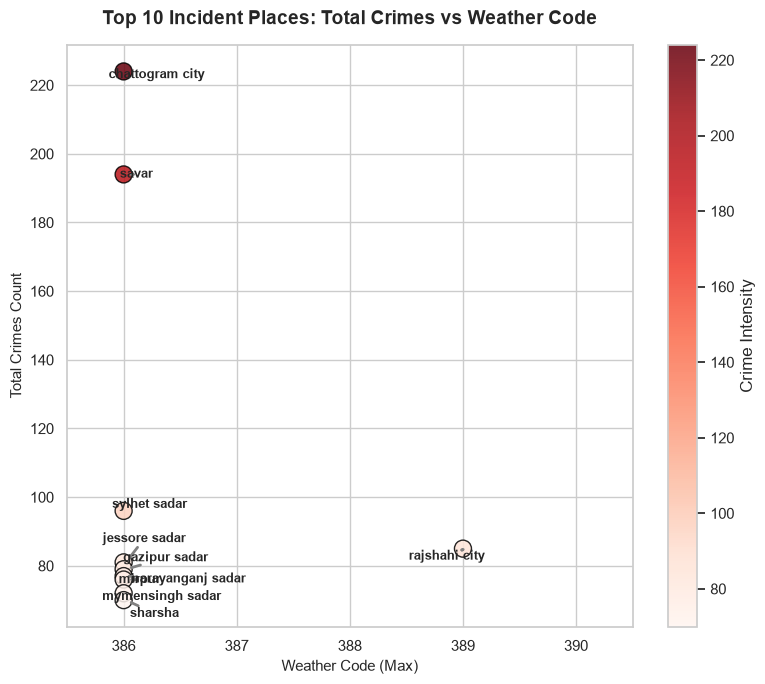

In [1005]:
plt.figure(figsize=(8,7))
sns.set_theme(style="whitegrid")

scatter = plt.scatter(
    x=top_10_crime_weather.weather_code,
    y=top_10_crime_weather.total_crimes,
    s=150,
    c=top_10_crime_weather.total_crimes,
    cmap='Reds',
    edgecolors='black',
    alpha=0.85
)
text=[]
for idx, row in top_10_crime_weather.iterrows():
    text.append(
        plt.text(
            x=row['weather_code']+0.02,
            y=row['total_crimes'],
            s=idx,
            fontsize=9,
            fontweight='bold',
            verticalalignment='center'
        )
    )
adjust_text(text, arrowprops=dict(arrowstyle="->", color='gray', lw=2))
plt.title("Top 10 Incident Places: Total Crimes vs Weather Code", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Weather Code (Max)", fontsize=11)
plt.ylabel("Total Crimes Count", fontsize=11)
plt.xlim(top_10_crime_weather['weather_code'].min() - 0.5, 
         top_10_crime_weather['weather_code'].max() + 1.5)

cbar = plt.colorbar(scatter)
cbar.set_label('Crime Intensity')

plt.tight_layout()
plt.show()

## Observation
- It shows crime occurs most often time in heavy rainy days.

In [1006]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          6574 non-null   int64  
 1   incident_week           6574 non-null   int64  
 2   incident_weekday        6574 non-null   str    
 3   weekend                 6574 non-null   int64  
 4   part_of_the_day         6574 non-null   str    
 5   latitude                6574 non-null   float64
 6   longitude               6574 non-null   float64
 7   incident_place          6574 non-null   str    
 8   incident_district       6574 non-null   str    
 9   incident_division       6574 non-null   str    
 10  max_temp                6574 non-null   int64  
 11  avg_temp                6574 non-null   int64  
 12  min_temp                6574 non-null   int64  
 13  weather_code            6574 non-null   int64  
 14  precip                  6574 non-null   float64
 15

In [1007]:
df["crime"].unique()

<StringArray>
['murder', 'rape', 'assault', 'bodyfound', 'kidnap', 'robbery']
Length: 6, dtype: str

## Context Aggregation Dataset

In [1008]:
context_df = df.groupby(["incident_place", "incident_weekday", "part_of_the_day"]).agg(
    total_crimes = ("crime","count"),
    total_murders = ("crime", lambda x: (x=="murder").sum()),
    total_rapes = ("crime", lambda x: (x=="rape").sum()),
    total_assaults = ("crime", lambda x: (x=="assault").sum()),
    total_bodyfounds = ("crime", lambda x: (x=="bodyfound").sum()),
    total_kidnaps = ("crime", lambda x: (x=="kidnap").sum()),
    total_robberys = ("crime", lambda x: (x=="robbery").sum()),
    latitude = ("latitude", "mean"),
    longitude = ("longitude", "mean"),
    temp_mode = ("avg_temp", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    season_mode = ("season", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    humidity_mean = ("humidity", "mean"),
    visibility_mean = ("visibility", "mean"),
    weather_code_mode = ("weather_code", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    precip_mean = ("precip", "mean"),
    cloudcover_mean = ("cloudcover","mean"),
    heatindex_mean = ("heatindex","mean"),
    household = ("household", "max"),
    male_population = ("male_population", "max"),
    female_population = ("female_population", "max"),
    total_population = ("total_population", "max"),
    gender_ration = ("gender_ration", "max"),
    household_size = ("average_household_size", "max"),
    density_kmsq = ("density_per_kmsq", "max"),
    religious_institution = ("religious_institution", "max"),
    playground = ("playground", "max"),
    park = ("park", "max"),
    police_station = ("police_station", "max"),
    cyber_cafe = ("cyber_cafe", "max"),
    school = ("school", "max"),
    college = ("college", "max"),
    cinema = ("cinema", "max") 
)

In [1009]:
print(context_df.head())

                                                 total_crimes  total_murders  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                     1              0   
                                night                       1              0   
               saturday         night                       5              2   
               sunday           morning                     1              1   
                                night                       1              0   

                                                 total_rapes  total_assaults  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                    1               0   
                                night                      1               0   
               saturday         night                      0               0   
               sunday           morning

In [1010]:
total_rows = context_df.shape[0]
filtered_rows = context_df[context_df["total_crimes"]==1].shape[0]

percentage = filtered_rows/total_rows
print(f"Percentage of total crime(1): {percentage}")

Percentage of total crime(1): 0.6624548736462094


## Distribution Analysis

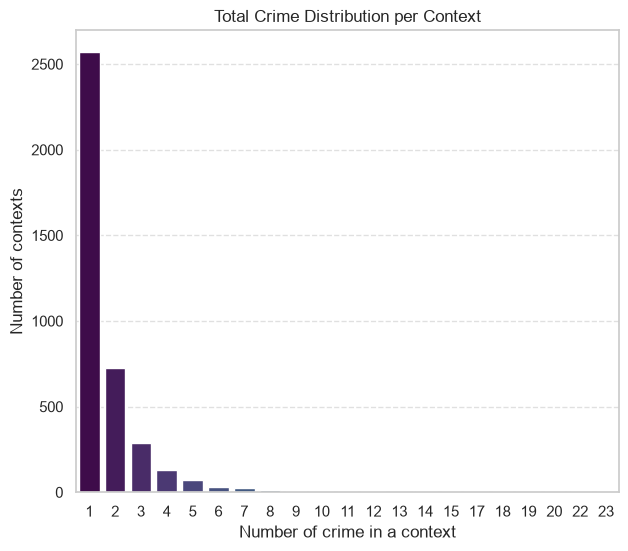

In [1011]:
#total crime distribution
crime_dist = context_df["total_crimes"].value_counts().sort_index()
# print(crime_dist)

plt.figure(figsize=(7,6))
sns.barplot(x=crime_dist.index, y=crime_dist.values, hue=crime_dist.index, palette='viridis', legend=False)
plt.title("Total Crime Distribution per Context")
plt.xlabel("Number of crime in a context")
plt.ylabel("Number of contexts")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

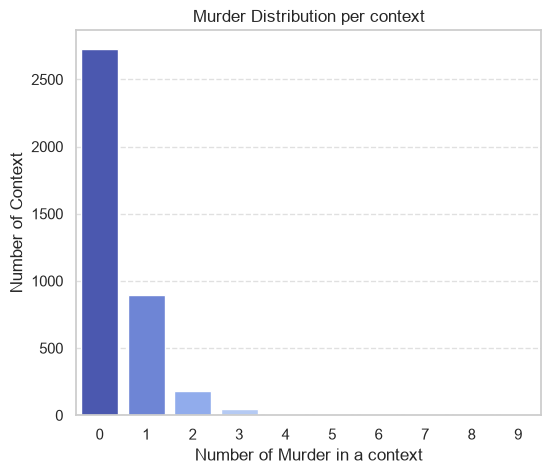

In [1012]:
#murder count distribution
murder_dist = context_df["total_murders"].value_counts().sort_index()

plt.figure(figsize=(6,5))
sns.barplot(x=murder_dist.index, y=murder_dist.values, hue=murder_dist.index, palette="coolwarm", legend=False)
plt.title("Murder Distribution per context")
plt.xlabel("Number of Murder in a context")
plt.ylabel("Number of Context")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

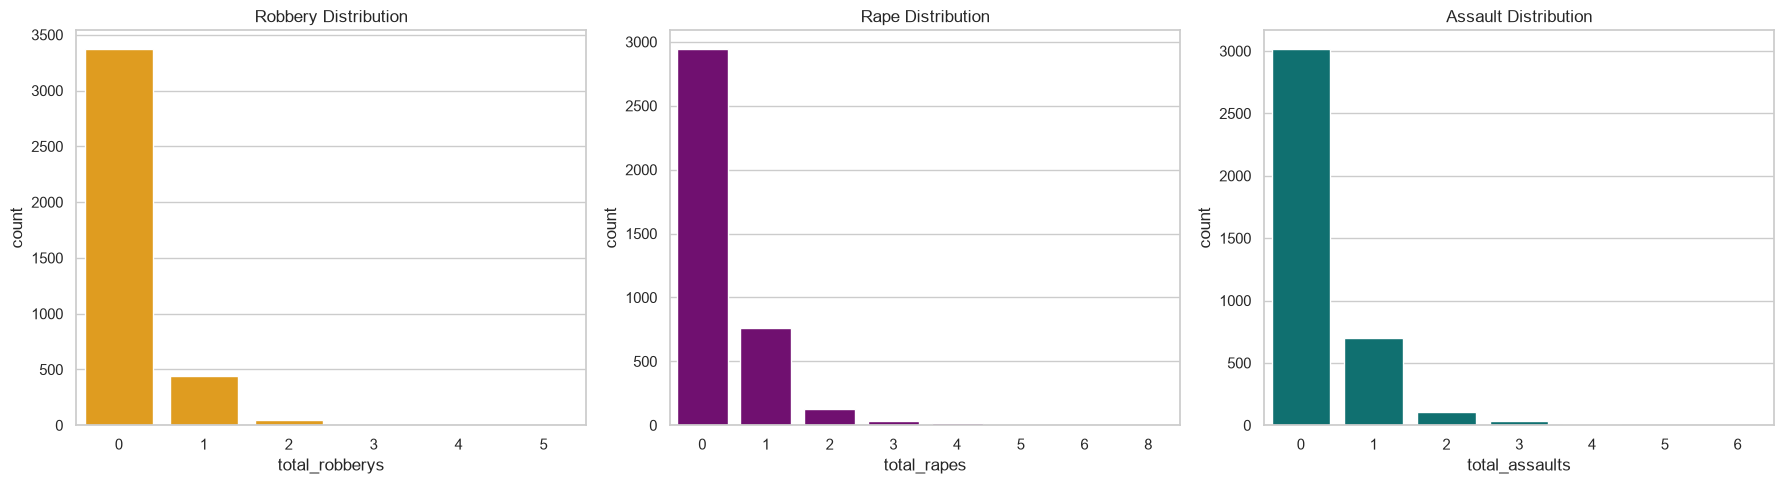

In [1013]:
#rape/robbery/assault distribution

fig, ax = plt.subplots(1, 3, figsize=(18,5))

#robbery distribution
sns.countplot(ax=ax[0], data=context_df, x="total_robberys", color='orange')
ax[0].set_title("Robbery Distribution")

#rape distribution
sns.countplot(ax=ax[1], data=context_df, x='total_rapes', color="purple")
ax[1].set_title("Rape Distribution")

#assault Distribution
sns.countplot(ax=ax[2], data=context_df, x="total_assaults", color="teal")
ax[2].set_title("Assault Distribution")

plt.tight_layout()
plt.show()

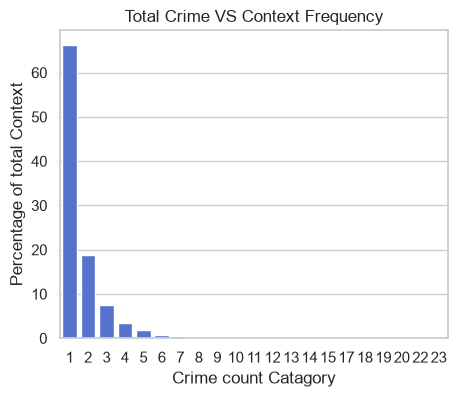

In [1014]:
#total crime vs crime frequency
crime_freq_pct = context_df["total_crimes"].value_counts(normalize=True) * 100

plt.figure(figsize=(5,4))
sns.barplot(x=crime_freq_pct.index, y=crime_freq_pct.values, color="royalblue")
plt.title("Total Crime VS Context Frequency")
plt.xlabel("Crime count Catagory")
plt.ylabel("Percentage of total Context")
plt.show()


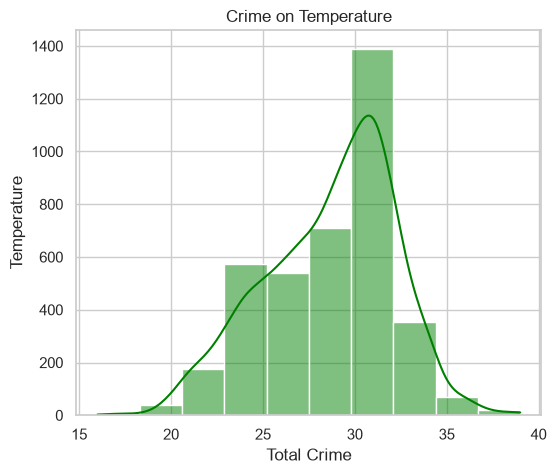

In [1015]:
#temparature vs crime
plt.figure(figsize=(6,5))
sns.histplot(data=context_df, x="temp_mode", kde=True, bins=10, color="green")
plt.title("Crime on Temperature")
plt.xlabel("Total Crime")
plt.ylabel("Temperature")
plt.show()

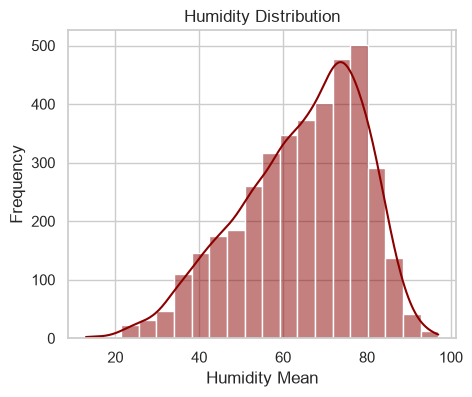

In [1016]:
#humidity distribution

plt.figure(figsize=(5,4))
sns.histplot(data=context_df, x="humidity_mean", kde=True, color="darkred", bins=20)
plt.title("Humidity Distribution")
plt.xlabel("Humidity Mean")
plt.ylabel("Frequency")
plt.show()

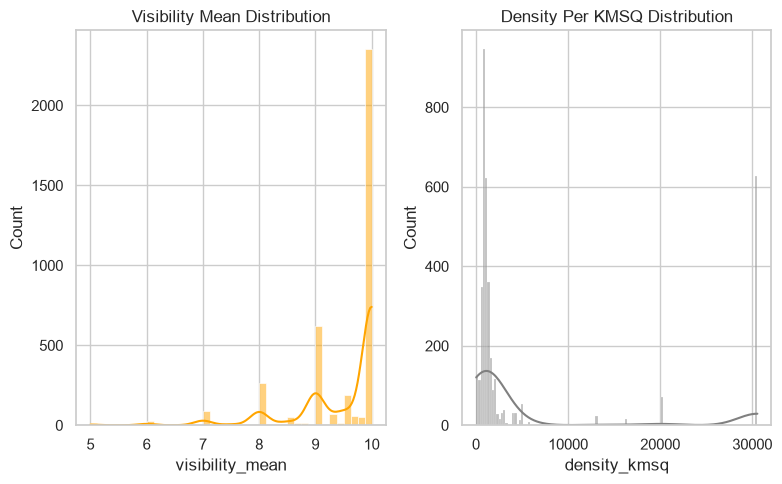

In [1017]:
#visibility and density
fig, ax = plt.subplots(1,2, figsize=(8,5))

sns.histplot(ax=ax[0], data=context_df, x="visibility_mean", kde=True, color="orange")
ax[0].set_title("Visibility Mean Distribution")

sns.histplot(ax=ax[1], data=context_df, x="density_kmsq", kde=True, color="gray")
ax[1].set_title("Density Per KMSQ Distribution")

plt.tight_layout()
plt.show()

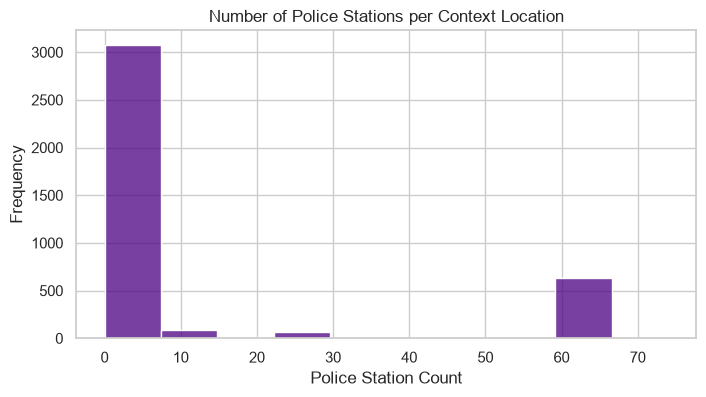

In [1018]:
#police station distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=context_df, x='police_station', kde=False, color='indigo', bins=10)
plt.title("Number of Police Stations per Context Location")
plt.xlabel("Police Station Count")
plt.ylabel("Frequency")
plt.show()


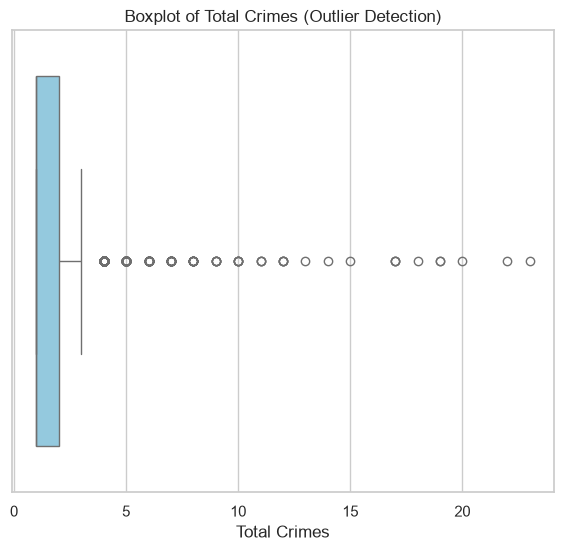

In [1019]:
#outlier check
plt.figure(figsize=(7,6))
sns.boxplot(data=context_df, x="total_crimes", color="skyblue")
plt.title("Boxplot of Total Crimes (Outlier Detection)")
plt.xlabel("Total Crimes")
plt.show()

In [1020]:
top_20_crime_context = context_df["total_crimes"].sort_values(ascending=False).head(20)
print(top_20_crime_context)

incident_place    incident_weekday  part_of_the_day
savar             friday            night              23
chattogram city   tuesday           night              22
savar             saturday          night              20
chattogram city   sunday            night              19
savar             thursday          night              19
                  tuesday           night              18
                  sunday            night              17
chattogram city   friday            night              17
                  monday            night              17
                  wednesday         night              15
savar             wednesday         night              14
chattogram city   saturday          night              13
gazipur sadar     tuesday           night              12
mymensingh sadar  tuesday           night              12
bogra sadar       monday            night              12
chattogram city   monday            morning            12
savar             th

In [1021]:
context_df.head()

total_crimes  total_murders  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                     1              0   
                                night                       1              0   
               saturday         night                       5              2   
               sunday           morning                     1              1   
                                night                       1              0   

                                                 total_rapes  total_assaults  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                    1               0   
                                night                      1               0   
               saturday         night                      0               0   
               sunday           morning                    0               0   
                                night                      0               0   

                                                 total_bodyfounds  \
incident_place incident_weekday part_of_the_day                     
abhaynagar     friday           morning                         0   
                                night                           0   
               saturday         night                           3   
               sunday           morning                         0   
                                night                           1   

                                                 total_kidnaps  \
incident_place incident_weekday part_of_the_day                  
abhaynagar     friday           morning                      0   
                                night                        0   
               saturday         night                        0   
               sunday           morning                      0   
                                night                        0   

                                                 total_robberys  latitude  \
incident_place incident_weekday part_of_the_day                             
abhaynagar     friday           morning                       0  23.01667   
                                night                         0  23.01667   
               saturday         night                         0  23.01667   
               sunday           morning                       0  23.01667   
                                night                         0  23.01667   

                                                 longitude  temp_mode  ...  \
incident_place incident_weekday part_of_the_day                        ...   
abhaynagar     friday           morning           89.43333         32  ...   
                                night             89.43333         27  ...   
               saturday         night             89.43333         30  ...   
               sunday           morning           89.43333         29  ...   
                                night             89.43333         32  ...   

                                                household_size  density_kmsq  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                    4.2          1062   
                                night                      4.2          1062   
               saturday         night                      4.2          1062   
               sunday           morning                    4.2          1062   
                                night                      4.2          1062   

                                                 religious_institution  \
incident_place incident_weekday part_of_the_day                          
abhaynagar     friday           morning                            615   
                                night                              615   
               saturday         nigh

In [1022]:
#crime frequency calculation
df["incident_weekday"].unique()

<StringArray>
['wednesday', 'tuesday', 'friday', 'thursday', 'sunday', 'saturday', 'monday']
Length: 7, dtype: str

In [1023]:
df.head()

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,latitude,longitude,incident_place,incident_district,incident_division,...,literacy_rate,religious_institution,playground,park,police_station,cyber_cafe,school,college,cinema,crime
0,7,29,wednesday,0,morning,23.774569,90.355292,adabor,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
1,1,2,wednesday,0,night,23.774569,90.355292,adabor,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
2,1,4,tuesday,0,night,23.769808,90.351595,adabor,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
3,3,9,friday,1,night,23.728907,90.417137,aftabnagar,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
4,8,34,thursday,0,night,23.847177,90.404133,airport,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder


In [1024]:
df[df["crime"]==0].count().sum()

np.int64(0)

### Therefore, there is no non crime events in this dataset. This is only incident dataset. So we can't calculate the probability, we only can derived Relative Crime Frequency/Crime Frequency. 

In [1025]:
df["place_total_crime"] = (
    df.groupby("incident_place")["crime"].transform("count")
)

df[["incident_place","incident_weekday","part_of_the_day", "crime", "place_total_crime"]]

,incident_place,incident_weekday,part_of_the_day,crime,place_total_crime
0,adabor,wednesday,morning,murder,8
1,adabor,wednesday,night,murder,8
2,adabor,tuesday,night,murder,8
3,aftabnagar,friday,night,murder,2
4,airport,thursday,night,murder,4
...,...,...,...,...,...
6569,tongibari,tuesday,night,robbery,9
6570,tongibari,saturday,night,robbery,9
6571,tongibari,tuesday,night,robbery,9
6572,zakiganj,wednesday,night,robbery,4


#### Due to the absence of chronological timestamps, forecasting crime frequency was not feasible. Therefore, we estimated relative crime frequency using historical context aggregation.

In [1026]:
context_count = (
    df.groupby([
        "incident_place",
        "incident_weekday",
        "part_of_the_day"
    ])["crime"].count().rename("context_count")
)

In [1027]:
place_total = (
    df.groupby("incident_place")["crime"]
      .count()
      .rename("place_total")
)

In [1028]:
context_count.index.get_level_values(0).map(place_total)

context_crime_frequency = context_count/context_count.index.get_level_values(0).map(place_total)

In [1029]:
context_crime_frequency

incident_place  incident_weekday  part_of_the_day
abhaynagar      friday            morning            0.055556
                                  night              0.055556
                saturday          night              0.277778
                sunday            morning            0.055556
                                  night              0.055556
                                                       ...   
zianagar        saturday          noon               0.125000
                thursday          morning            0.125000
                                  night              0.125000
                tuesday           night              0.125000
                wednesday         night              0.125000
Length: 3878, dtype: float64

In [1030]:
context_df = context_df.join(context_crime_frequency.rename("crime_frequency"))

In [1031]:

weights = {
    "murder":10,
    "rape":9,
    "kidnap":8,
    "bodyfound":7,
    "robbery":6,
    "assault":5
}

In [1032]:
context_df["crime_severity_raw"] = (
    (context_df["total_murders"] * weights["murder"]) +
    (context_df["total_rapes"] * weights["rape"]) +
    (context_df["total_kidnaps"] * weights["kidnap"]) +
    (context_df["total_bodyfounds"] * weights["bodyfound"]) +
    (context_df["total_robberys"] * weights["robbery"]) +
    (context_df["total_assaults"] * weights["assault"])
)

max_possible_severity = context_df["total_crimes"].max() * weights["murder"]

In [1033]:
context_df["crime_severity"] = (context_df["crime_severity_raw"] / max_possible_severity).clip(0,1)

In [1034]:
context_df.head()

total_crimes  total_murders  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                     1              0   
                                night                       1              0   
               saturday         night                       5              2   
               sunday           morning                     1              1   
                                night                       1              0   

                                                 total_rapes  total_assaults  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                    1               0   
                                night                      1               0   
               saturday         night                      0               0   
               sunday           morning                    0               0   
                                night                      0               0   

                                                 total_bodyfounds  \
incident_place incident_weekday part_of_the_day                     
abhaynagar     friday           morning                         0   
                                night                           0   
               saturday         night                           3   
               sunday           morning                         0   
                                night                           1   

                                                 total_kidnaps  \
incident_place incident_weekday part_of_the_day                  
abhaynagar     friday           morning                      0   
                                night                        0   
               saturday         night                        0   
               sunday           morning                      0   
                                night                        0   

                                                 total_robberys  latitude  \
incident_place incident_weekday part_of_the_day                             
abhaynagar     friday           morning                       0  23.01667   
                                night                         0  23.01667   
               saturday         night                         0  23.01667   
               sunday           morning                       0  23.01667   
                                night                         0  23.01667   

                                                 longitude  temp_mode  ...  \
incident_place incident_weekday part_of_the_day                        ...   
abhaynagar     friday           morning           89.43333         32  ...   
                                night             89.43333         27  ...   
               saturday         night             89.43333         30  ...   
               sunday           morning           89.43333         29  ...   
                                night             89.43333         32  ...   

                                                playground  park  \
incident_place incident_weekday part_of_the_day                    
abhaynagar     friday           morning                 11     0   
                                night                   11     0   
               saturday         night                   11     0   
               sunday           morning                 11     0   
                                night                   11     0   

                                                 police_station  cyber_cafe  \
incident_place incident_weekday part_of_the_day                               
abhaynagar     friday           morning                       8           5   
                                night                         8           5   
               saturday         night                         8           5   
               sunday

In [1035]:
env_features = [
    "temp_mode",
    "humidity_mean",
    "visibility_mean",
    "weather_code_mode",
    "precip_mean",
    "cloudcover_mean",
    "heatindex_mean"
]

location_features = [
    "density_kmsq",
    "total_population",
    "police_station",
    "park",
    "playground",
    "school",
    "college",
    "religious_institution",
    "cinema",
    "cyber_cafe"
]



In [1036]:
X_env = context_df[env_features]
y = context_df["crime_severity"]
y_freq = context_df["crime_frequency"]

## Reasoning
- For only calculate feature importance model.fit() is fine. But we want to evaluate our model so we will go through the train-test process

## Environment Importance Calculation --RF

In [1037]:
X_env_train, X_env_test, y_train, y_test = train_test_split(X_env, y, test_size=0.2, random_state=42)

In [1038]:
env_scaler = MinMaxScaler()

X_env_train = pd.DataFrame(
    env_scaler.fit_transform(X_env_train),
    columns=env_features,
    index=X_env_train.index
)

X_env_test = pd.DataFrame(
    env_scaler.transform(X_env_test),
    columns=env_features,
    index=X_env_test.index
)

In [1039]:
env_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)
env_model.fit(X_env_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [1040]:
y_pred = env_model.predict(X_env_test)
R2_score = r2_score(y_test, y_pred)
print(R2_score)

0.5164893796638657


In [1041]:
env_model.feature_importances_

array([0.05888185, 0.06811466, 0.60637144, 0.10272673, 0.05811615,
       0.04251892, 0.06327024])

visibility_mean      0.606371
weather_code_mode    0.102727
humidity_mean        0.068115
heatindex_mean       0.063270
temp_mode            0.058882
precip_mean          0.058116
cloudcover_mean      0.042519
dtype: float64


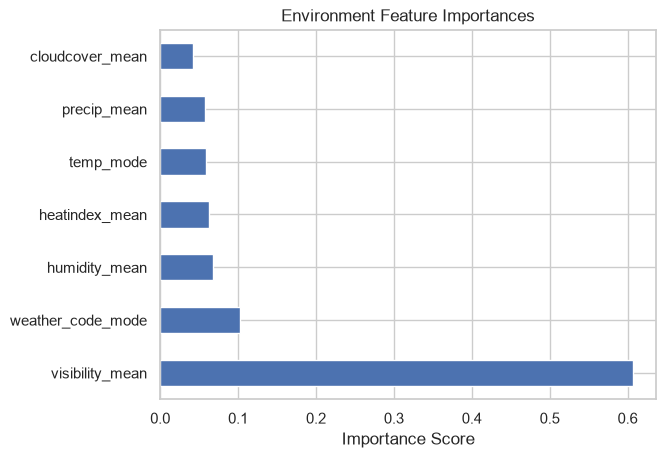

In [1042]:
env_feature_importance = pd.Series(env_model.feature_importances_, index=X_env_train.columns)
print(env_feature_importance.nlargest(7))

# Plot using pandas built-in plotting wrapper
env_feature_importance.nlargest(7).plot(kind='barh')
plt.title("Environment Feature Importances")
plt.xlabel("Importance Score")
plt.show()


In [1043]:
#convert this importance into dataframe
env_importance = pd.DataFrame({
    "feature":X_env.columns,
    "importance":env_model.feature_importances_}
).sort_values("importance", ascending=False)

In [1044]:
print(env_importance)

             feature  importance
2    visibility_mean    0.606371
3  weather_code_mode    0.102727
1      humidity_mean    0.068115
6     heatindex_mean    0.063270
0          temp_mode    0.058882
4        precip_mean    0.058116
5    cloudcover_mean    0.042519


## Statistical Relationship Ques: How influential environment features to crime frequency?

In [1045]:
X_env_train, X_env_test, y_freq_train, y_freq_test = train_test_split(X_env, y_freq, test_size=0.2, random_state=42)

In [1046]:
env_model.fit(X_env_train, y_freq_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [1047]:
y_freq_env_pred = env_model.predict(X_env_test)
r2_score_freq = r2_score(y_freq_test, y_freq_env_pred)
print(r2_score_freq)

-0.005959260407740308


## Location Importance Calculation -- RF

In [1048]:
X_loc = context_df[location_features]
y = context_df["crime_severity"]
y_freq = context_df["crime_frequency"]

In [1049]:
X_loc_train, X_loc_test, y_train, y_test = train_test_split(X_loc, y, test_size=0.2, random_state=42)

In [1050]:
loc_scaler = MinMaxScaler()

X_loc_train = pd.DataFrame(
    loc_scaler.fit_transform(X_loc_train),
    columns=location_features,
    index=X_loc_train.index
)

X_loc_test = pd.DataFrame(
    loc_scaler.transform(X_loc_test),
    columns=location_features,
    index=X_loc_test.index
)

In [1051]:
loc_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

In [1052]:
loc_model.fit(X_loc_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [1053]:
yPred_loc = loc_model.predict(X_loc_test)

In [1054]:
loc_model.feature_importances_

array([0.12811175, 0.21294518, 0.02289388, 0.13663588, 0.05532411,
       0.04416171, 0.05068822, 0.279646  , 0.04395616, 0.0256371 ])

In [1055]:
R2_score = r2_score(y_test, yPred_loc)
print(R2_score)

0.09509795904477758


religious_institution    0.279646
total_population         0.212945
park                     0.136636
density_kmsq             0.128112
playground               0.055324
college                  0.050688
school                   0.044162
cinema                   0.043956
cyber_cafe               0.025637
police_station           0.022894
dtype: float64


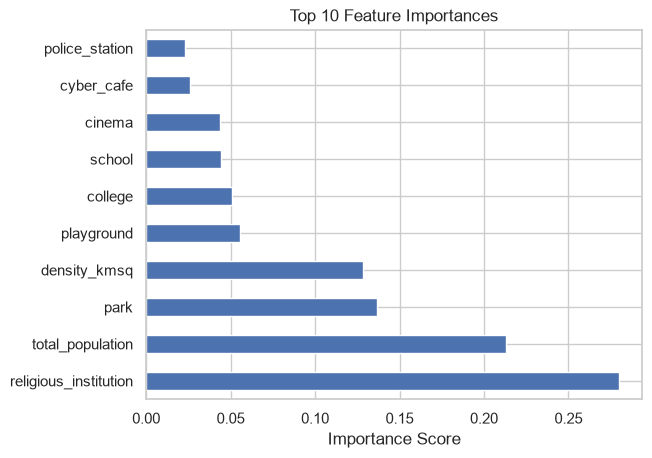

In [1056]:
loc_feat_importance = pd.Series(loc_model.feature_importances_, index=X_loc_train.columns)
print(loc_feat_importance.nlargest(10))

# Plot using pandas built-in plotting wrapper
loc_feat_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.show()

In [1057]:
loc_importance = pd.DataFrame({
    "location":X_loc.columns,
    "importance":loc_model.feature_importances_
}).sort_values("importance", ascending=False)

In [1058]:
print(loc_importance)

                location  importance
7  religious_institution    0.279646
1       total_population    0.212945
3                   park    0.136636
0           density_kmsq    0.128112
4             playground    0.055324
6                college    0.050688
5                 school    0.044162
8                 cinema    0.043956
9             cyber_cafe    0.025637
2         police_station    0.022894


## Statistical Relationship Ques: How influential location features to crime frequency?

In [1059]:
X_loc_train, X_loc_test, y_freq_train, y_freq_test = train_test_split(X_loc, y_freq, test_size=0.2, random_state=42)

In [1060]:
loc_model.fit(X_loc_train, y_freq_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [1061]:
y_loc_freq_pred = loc_model.predict(X_loc_test)
r2_score_freq_loc = r2_score(y_freq_test, y_loc_freq_pred)
print(r2_score_freq_loc)

0.20935818346404889


In [1062]:
print(env_importance)


             feature  importance
2    visibility_mean    0.606371
3  weather_code_mode    0.102727
1      humidity_mean    0.068115
6     heatindex_mean    0.063270
0          temp_mode    0.058882
4        precip_mean    0.058116
5    cloudcover_mean    0.042519


## Location related features showed stronger predictive association with historical relative crime frequency than environmental features in our dataset.

In [1063]:
#environment score calculation and mapping
env_weights = dict(zip(env_importance["feature"], env_importance["importance"]))

In [1064]:
X_env_all_scaled = pd.DataFrame(
    env_scaler.transform(context_df[env_features]),
    columns=env_features,
    index=context_df.index
)

context_df["env_score"] = sum(
    X_env_all_scaled[feature] * weight
    for feature, weight in env_weights.items()
)

In [1065]:
#location score calculation and mapping
loc_weights = dict(zip(loc_importance["location"], loc_importance["importance"]))

In [1066]:
X_loc_all_scaled = pd.DataFrame(
    loc_scaler.transform(context_df[location_features]),
    columns=location_features,
    index=context_df.index
)

context_df["loc_score"] = sum(
    X_loc_all_scaled[location] * weight
    for location, weight in loc_weights.items()
)

In [1067]:
print(context_df["env_score"].min(), context_df["env_score"].max())
print(context_df["loc_score"].min(), context_df["loc_score"].max())

0.1544277286592276 0.8799762539018269
0.0024051259267536844 0.9619931804678582


In [1068]:
context_df.head()

total_crimes  total_murders  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                     1              0   
                                night                       1              0   
               saturday         night                       5              2   
               sunday           morning                     1              1   
                                night                       1              0   

                                                 total_rapes  total_assaults  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                    1               0   
                                night                      1               0   
               saturday         night                      0               0   
               sunday           morning                    0               0   
                                night                      0               0   

                                                 total_bodyfounds  \
incident_place incident_weekday part_of_the_day                     
abhaynagar     friday           morning                         0   
                                night                           0   
               saturday         night                           3   
               sunday           morning                         0   
                                night                           1   

                                                 total_kidnaps  \
incident_place incident_weekday part_of_the_day                  
abhaynagar     friday           morning                      0   
                                night                        0   
               saturday         night                        0   
               sunday           morning                      0   
                                night                        0   

                                                 total_robberys  latitude  \
incident_place incident_weekday part_of_the_day                             
abhaynagar     friday           morning                       0  23.01667   
                                night                         0  23.01667   
               saturday         night                         0  23.01667   
               sunday           morning                       0  23.01667   
                                night                         0  23.01667   

                                                 longitude  temp_mode  ...  \
incident_place incident_weekday part_of_the_day                        ...   
abhaynagar     friday           morning           89.43333         32  ...   
                                night             89.43333         27  ...   
               saturday         night             89.43333         30  ...   
               sunday           morning           89.43333         29  ...   
                                night             89.43333         32  ...   

                                                police_station  cyber_cafe  \
incident_place incident_weekday part_of_the_day                              
abhaynagar     friday           morning                      8           5   
                                night                        8           5   
               saturday         night                        8           5   
               sunday           morning                      8           5   
                                night                        8           5   

                                                 school  college  cinema  \
incident_place incident_weekday part_of_the_day                            
abhaynagar     friday           morning              52       10       2   
                                night                52       10       2   
               saturday         night     

In [1069]:
context_df.describe()

,total_crimes,total_murders,total_rapes,total_assaults,total_bodyfounds,total_kidnaps,total_robberys,latitude,longitude,temp_mode,...,police_station,cyber_cafe,school,college,cinema,crime_frequency,crime_severity_raw,crime_severity,env_score,loc_score
count,3878.000000,3878.000000,3878.000000,3878.000000,3878.000000,3878.00000,3878.000000,3878.000000,3878.000000,3878.000000,...,3878.000000,3878.000000,3878.000000,3878.000000,3878.000000,3878.000000,3878.000000,3878.000000,3878.000000,3878.000000
mean,1.695204,0.391439,0.307633,0.282878,0.391181,0.16787,0.154203,23.913191,90.193336,28.669675,...,12.620165,82.435018,76.427540,16.170449,8.159618,0.169933,13.103920,0.056974,0.701888,0.236865
std,1.556082,0.743608,0.642810,0.612543,0.749444,0.45813,0.447325,1.055136,0.986142,3.549708,...,21.213164,174.609609,76.974588,21.524933,14.107716,0.199715,12.488624,0.054298,0.084399,0.323645
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,20.866700,88.141700,16.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.004464,5.000000,0.021739,0.154428,0.002405
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,23.180315,89.382832,26.000000,...,2.000000,0.000000,28.000000,4.000000,1.000000,0.062500,7.000000,0.030435,0.669351,0.065279
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,23.816700,90.318100,29.000000,...,3.000000,1.000000,43.500000,7.000000,2.000000,0.103448,9.000000,0.039130,0.703064,0.090997
75%,2.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000,24.633300,90.650000,31.000000,...,6.000000,13.000000,74.000000,13.000000,4.000000,0.200000,15.000000,0.065217,0.743843,0.164404
max,23.000000,9.000000,8.000000,6.000000,11.000000,5.00000,5.000000,26.482740,92.437760,39.000000,...,74.000000,478.000000,242.000000,64.000000,40.000000,1.000000,191.000000,0.830435,0.879976,0.961993


### Risk Weighting Rationale

The 40-30-20-10 weighting scheme is a domain-informed design choice,
not a statistically learned or causally estimated weighting.

The priority hierarchy is:

Crime Severity > Crime Frequency > Location > Environment

- Severity: represents the potential harm associated with the crime type.
- Frequency: represents recurring historical concentration of incidents.
- Location: represents relatively persistent spatial characteristics.
- Environment: represents dynamic contextual conditions that may influence
  crime occurrence.

These weights should be validated through sensitivity analysis and,
where possible, expert/domain feedback.

### Domain-informed risk priority:
### Severity > Frequency > Location > Environment

In [1070]:
#crime risk score
context_df["crime_risk_score"] = (
    0.40 * context_df["crime_severity"] +
    0.30 * context_df["crime_frequency"] +
    0.20 * context_df["loc_score"] +
    0.10 * context_df["env_score"]
)

In [1071]:
baseline_output = context_df[["latitude", "longitude", "crime_risk_score"]]

In [1072]:
print(baseline_output)

                                                 latitude  longitude  \
incident_place incident_weekday part_of_the_day                        
abhaynagar     friday           morning          23.01667   89.43333   
                                night            23.01667   89.43333   
               saturday         night            23.01667   89.43333   
               sunday           morning          23.01667   89.43333   
                                night            23.01667   89.43333   
...                                                   ...        ...   
zianagar       saturday         noon             22.50439   89.97897   
               thursday         morning          22.50439   89.97897   
                                night            22.50439   89.97897   
               tuesday          night            22.50439   89.97897   
               wednesday        night            22.50439   89.97897   

                                                 crime_risk_sco

## Specific Crime Wise Risk Score Calculation & Mapping

In [1073]:
context_df["murder_ratio"] = context_df["total_murders"] / context_df["total_crimes"]

context_df["rape_ratio"] = context_df["total_rapes"] / context_df["total_crimes"]

context_df["kidnap_ratio"] = context_df["total_kidnaps"] / context_df["total_crimes"]

context_df["bodyfound_ratio"] = context_df["total_bodyfounds"] / context_df["total_crimes"]

context_df["robbery_ratio"] = context_df["total_robberys"] / context_df["total_crimes"]

context_df["assault_ratio"] = context_df["total_assaults"] / context_df["total_crimes"]

In [1074]:
context_df[
[
"murder_ratio",
"rape_ratio",
"robbery_ratio",
"assault_ratio",
"kidnap_ratio",
"bodyfound_ratio"
]
].head()

murder_ratio  rape_ratio  \
incident_place incident_weekday part_of_the_day                             
abhaynagar     friday           morning                   0.0         1.0   
                                night                     0.0         1.0   
               saturday         night                     0.4         0.0   
               sunday           morning                   1.0         0.0   
                                night                     0.0         0.0   

                                                 robbery_ratio  assault_ratio  \
incident_place incident_weekday part_of_the_day                                 
abhaynagar     friday           morning                    0.0            0.0   
                                night                      0.0            0.0   
               saturday         night                      0.0            0.0   
               sunday           morning                    0.0            0.0   
                                night                      0.0            0.0   

                                                 kidnap_ratio  bodyfound_ratio  
incident_place incident_weekday part_of_the_day                                 
abhaynagar     friday           morning                   0.0              0.0  
                                night                     0.0              0.0  
               saturday         night                     0.0              0.6  
               sunday           morning                   0.0              0.0  
                                night                     0.0              1.0

In [1075]:
context_df

total_crimes  total_murders  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                     1              0   
                                night                       1              0   
               saturday         night                       5              2   
               sunday           morning                     1              1   
                                night                       1              0   
...                                                       ...            ...   
zianagar       saturday         noon                        1              1   
               thursday         morning                     1              1   
                                night                       1              1   
               tuesday          night                       1              0   
               wednesday        night                       1              0   

                                                 total_rapes  total_assaults  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                    1               0   
                                night                      1               0   
               saturday         night                      0               0   
               sunday           morning                    0               0   
                                night                      0               0   
...                                                      ...             ...   
zianagar       saturday         noon                       0               0   
               thursday         morning                    0               0   
                                night                      0               0   
               tuesday          night                      0               0   
               wednesday        night                      0               0   

                                                 total_bodyfounds  \
incident_place incident_weekday part_of_the_day                     
abhaynagar     friday           morning                         0   
                                night                           0   
               saturday         night                           3   
               sunday           morning                         0   
                                night                           1   
...                                                           ...   
zianagar       saturday         noon                            0   
               thursday         morning                         0   
                                night                           0   
               tuesday          night                           0   
               wednesday        night                           1   

                                                 total_kidnaps  \
incident_place incident_weekday part_of_the_day                  
abhaynagar     friday           morning                      0   
                                night                        0   
               saturday         night                        0   
               sunday           morning                      0   
                                night                        0   
...                                                        ...   
zianagar       saturday         noon                         0   
               thursday         morning                      0   
                                night                        0   
               tuesday          night                        0   
               wednesday        night                        0   

                                                 total_robberys  latitude  \
incident_place incident_weekday part_of_the_day                             
abhaynagar     friday           morning                 

In [1076]:
context_df["murder_risk"] = context_df["murder_ratio"] * context_df["crime_risk_score"]

context_df["rape_risk"] = context_df["rape_ratio"] * context_df["crime_risk_score"]

context_df["kidnap_risk"] = context_df["kidnap_ratio"] * context_df["crime_risk_score"]

context_df["bodyfound_risk"] = context_df["bodyfound_ratio"] * context_df["crime_risk_score"]

context_df["robbery_risk"] = context_df["robbery_ratio"] * context_df["crime_risk_score"]

context_df["assault_risk"] = context_df["assault_ratio"] * context_df["crime_risk_score"]

In [1077]:
baseline_output = context_df

In [1078]:
baseline_output

total_crimes  total_murders  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                     1              0   
                                night                       1              0   
               saturday         night                       5              2   
               sunday           morning                     1              1   
                                night                       1              0   
...                                                       ...            ...   
zianagar       saturday         noon                        1              1   
               thursday         morning                     1              1   
                                night                       1              1   
               tuesday          night                       1              0   
               wednesday        night                       1              0   

                                                 total_rapes  total_assaults  \
incident_place incident_weekday part_of_the_day                                
abhaynagar     friday           morning                    1               0   
                                night                      1               0   
               saturday         night                      0               0   
               sunday           morning                    0               0   
                                night                      0               0   
...                                                      ...             ...   
zianagar       saturday         noon                       0               0   
               thursday         morning                    0               0   
                                night                      0               0   
               tuesday          night                      0               0   
               wednesday        night                      0               0   

                                                 total_bodyfounds  \
incident_place incident_weekday part_of_the_day                     
abhaynagar     friday           morning                         0   
                                night                           0   
               saturday         night                           3   
               sunday           morning                         0   
                                night                           1   
...                                                           ...   
zianagar       saturday         noon                            0   
               thursday         morning                         0   
                                night                           0   
               tuesday          night                           0   
               wednesday        night                           1   

                                                 total_kidnaps  \
incident_place incident_weekday part_of_the_day                  
abhaynagar     friday           morning                      0   
                                night                        0   
               saturday         night                        0   
               sunday           morning                      0   
                                night                        0   
...                                                        ...   
zianagar       saturday         noon                         0   
               thursday         morning                      0   
                                night                        0   
               tuesday          night                        0   
               wednesday        night                        0   

                                                 total_robberys  latitude  \
incident_place incident_weekday part_of_the_day                             
abhaynagar     friday           morning                 

In [1079]:
#check every range is in (0,1)
print(context_df["env_score"].min(), context_df["env_score"].max())
print(context_df["loc_score"].min(), context_df["loc_score"].max())
print(context_df["crime_frequency"].min(), context_df["crime_frequency"].max())
print(context_df["crime_severity"].min(), context_df["crime_severity"].max())
print(context_df["crime_risk_score"].min(), context_df["crime_risk_score"].max())

0.1544277286592276 0.8799762539018269
0.0024051259267536844 0.9619931804678582
0.004464285714285714 1.0
0.021739130434782608 0.8304347826086956
0.0615184019998103 0.6111484268358663


In [1080]:
baseline_output = baseline_output.reset_index()

In [1081]:
baseline_output.head()

,incident_place,incident_weekday,part_of_the_day,total_crimes,total_murders,total_rapes,total_assaults,total_bodyfounds,total_kidnaps,total_robberys,...,kidnap_ratio,bodyfound_ratio,robbery_ratio,assault_ratio,murder_risk,rape_risk,kidnap_risk,bodyfound_risk,robbery_risk,assault_risk
0,abhaynagar,friday,morning,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.000000,0.133997,0.0,0.000000,0.0,0.0
1,abhaynagar,friday,night,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.000000,0.114303,0.0,0.000000,0.0,0.0
2,abhaynagar,saturday,night,5,2,0,0,3,0,0,...,0.0,0.6,0.0,0.0,0.097006,0.000000,0.0,0.145508,0.0,0.0
3,abhaynagar,sunday,morning,1,1,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.119957,0.000000,0.0,0.000000,0.0,0.0
4,abhaynagar,sunday,night,1,0,0,0,1,0,0,...,0.0,1.0,0.0,0.0,0.000000,0.000000,0.0,0.094141,0.0,0.0


In [1082]:
baseline_output = baseline_output[["incident_place","incident_weekday","part_of_the_day","latitude","longitude","crime_risk_score",
                                "murder_risk","rape_risk","kidnap_risk","bodyfound_risk","robbery_risk","assault_risk","total_crimes",
                                "total_murders","total_rapes","total_kidnaps","total_bodyfounds","total_robberys","total_assaults"]]

In [1083]:
#risk level generate from risk threshold 
def risk_level(score):

    if score < 0.20:
        return "Very Low"

    elif score < 0.35:
        return "Low"

    elif score < 0.50:
        return "Moderate"

    elif score < 0.70:
        return "High"

    else:
        return "Very High"


baseline_output["risk_level"] = baseline_output[
    "crime_risk_score"
].apply(risk_level)

In [1084]:
baseline_output["marker_radius"] = (
    5 +
    baseline_output["crime_risk_score"]*15
)

In [1085]:
#specific crime recomendation
crime_columns = [
    "murder_risk",
    "rape_risk",
    "kidnap_risk",
    "bodyfound_risk",
    "robbery_risk",
    "assault_risk"
]

baseline_output["dominant_crime"] = (
    baseline_output[crime_columns]
    .idxmax(axis=1)
)

In [1086]:
baseline_output.head(20)

,incident_place,incident_weekday,part_of_the_day,latitude,longitude,crime_risk_score,murder_risk,rape_risk,kidnap_risk,bodyfound_risk,...,total_crimes,total_murders,total_rapes,total_kidnaps,total_bodyfounds,total_robberys,total_assaults,risk_level,marker_radius,dominant_crime
0,abhaynagar,friday,morning,23.016670,89.433330,0.133997,0.000000,0.133997,0.000000,0.000000,...,1,0,1,0,0,0,0,Very Low,7.009959,rape_risk
1,abhaynagar,friday,night,23.016670,89.433330,0.114303,0.000000,0.114303,0.000000,0.000000,...,1,0,1,0,0,0,0,Very Low,6.714549,rape_risk
2,abhaynagar,saturday,night,23.016670,89.433330,0.242514,0.097006,0.000000,0.000000,0.145508,...,5,2,0,0,3,0,0,Low,8.637711,bodyfound_risk
3,abhaynagar,sunday,morning,23.016670,89.433330,0.119957,0.119957,0.000000,0.000000,0.000000,...,1,1,0,0,0,0,0,Very Low,6.799360,murder_risk
4,abhaynagar,sunday,night,23.016670,89.433330,0.094141,0.000000,0.000000,0.000000,0.094141,...,1,0,0,0,1,0,0,Very Low,6.412116,bodyfound_risk
5,abhaynagar,sunday,noon,23.016670,89.433330,0.112752,0.112752,0.000000,0.000000,0.000000,...,1,1,0,0,0,0,0,Very Low,6.691274,murder_risk
6,abhaynagar,thursday,afternoon,23.016670,89.433330,0.112361,0.000000,0.000000,0.000000,0.000000,...,1,0,0,0,0,0,1,Very Low,6.685421,assault_risk
7,abhaynagar,thursday,morning,23.016670,89.433330,0.120483,0.120483,0.000000,0.000000,0.000000,...,1,1,0,0,0,0,0,Very Low,6.807242,murder_risk
8,abhaynagar,thursday,noon,23.016670,89.433330,0.112745,0.000000,0.000000,0.000000,0.112745,...,1,0,0,0,1,0,0,Very Low,6.691182,bodyfound_risk
9,abhaynagar,tuesday,night,23.016670,89.433330,0.118972,0.000000,0.118972,0.000000,0.000000,...,1,0,1,0,0,0,0,Very Low,6.784580,rape_risk


In [1087]:
baseline_output.to_csv(
    r"D:\Projects\ai_powered_crime_hotspot\output\crime_map_baseline.csv",
    index=False
)

In [1088]:
current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

base_data_path = project_root/"output"/"crime_map_baseline.csv"

bs_df = pd.read_csv(base_data_path)

In [1089]:
bs_df.head(5)

,incident_place,incident_weekday,part_of_the_day,latitude,longitude,crime_risk_score,murder_risk,rape_risk,kidnap_risk,bodyfound_risk,...,total_crimes,total_murders,total_rapes,total_kidnaps,total_bodyfounds,total_robberys,total_assaults,risk_level,marker_radius,dominant_crime
0,abhaynagar,friday,morning,23.01667,89.43333,0.133997,0.000000,0.133997,0.0,0.000000,...,1,0,1,0,0,0,0,Very Low,7.009959,rape_risk
1,abhaynagar,friday,night,23.01667,89.43333,0.114303,0.000000,0.114303,0.0,0.000000,...,1,0,1,0,0,0,0,Very Low,6.714549,rape_risk
2,abhaynagar,saturday,night,23.01667,89.43333,0.242514,0.097006,0.000000,0.0,0.145508,...,5,2,0,0,3,0,0,Low,8.637711,bodyfound_risk
3,abhaynagar,sunday,morning,23.01667,89.43333,0.119957,0.119957,0.000000,0.0,0.000000,...,1,1,0,0,0,0,0,Very Low,6.799360,murder_risk
4,abhaynagar,sunday,night,23.01667,89.43333,0.094141,0.000000,0.000000,0.0,0.094141,...,1,0,0,0,1,0,0,Very Low,6.412116,bodyfound_risk


In [1090]:
bs_df.dominant_crime.value_counts()

dominant_crime
murder_risk       1037
bodyfound_risk     885
rape_risk          715
assault_risk       559
kidnap_risk        382
robbery_risk       300
Name: count, dtype: int64

In [1091]:
bs_df.dominant_crime.value_counts(normalize=True)*100

dominant_crime
murder_risk       26.740588
bodyfound_risk    22.821042
rape_risk         18.437339
assault_risk      14.414647
kidnap_risk        9.850438
robbery_risk       7.735946
Name: proportion, dtype: float64

In [1092]:
bs_df.shape

(3878, 22)